# LSCI220 Final Project: Narrative & Storytelling in Musical Lyrics
Noppachon Chaisongkhram | 300607581

## 1. Introduction
This project undertakes a comparative computational linguistic analysis of the lyrical styles of two distinctive alternative artists: Lana Del Rey and Sombr (Somber). Lana Del Rey is renowned for her cinematic, nostalgic storytelling, often weaving motifs of Americana, tragic romance, and grandeur into her work. In contrast, Sombr is recognised for a more contemporary, raw, and introspective style, frequently delving into personal and visceral narratives. The core aim of this investigation is to determine whether these subjectively perceived artistic differences are reflected in objective, quantifiable linguistic patterns within their song lyrics.

The analysis is structured around three specific research questions:

**Q1. Narrative Elements:**
Do Lana Del Rey's lyrics use more past-tense verbs and proper nouns, suggesting a storytelling style, while Sombr's use more first-person pronouns, suggesting raw confession?

**Q2. Lexical & Emotional Profile:**
Regarding vocabulary and emotional resonance, which artist employs a more diverse and sophisticated lexicon, and what are the dominant emotional tones conveyed through their lyrical content?

**Q3. Textual Complexity:**
Concerning the structural composition of the lyrics, do the syntactic structures and general readability metrics differ significantly between the two artists, potentially reflecting varying levels of narrative or poetic complexity?

This comparative analysis will be calculated via Part-of-Speech (POS) Tagging, Type-Token Ratio (TTR), Sentiment Analysis, and the Gunning Fog Index.
- **Part-of-Speech (POS) Tagging** was chosen because it categorises each word by its grammatical function, allowing us to quantify narrative elements like past-tense verbs, proper nouns, and personal pronouns.
- **Type-Token Ratio (TTR)** was chosen because it measures vocabulary diversity by comparing unique words to total words, indicating the lexical richness of an artist's lyrics.
- **Sentiment Analysis** was chosen because it algorithmically assesses the emotional tone of a text, revealing whether the lyrical content leans towards positive, negative, or neutral tones.
- **Gunning Fog Index** was chosen because it estimates the syntactic complexity and readability of a text based on sentence length and the proportion of complex words.

## 2. Setup & Data Collection via Genius API
We will use the `lyricsgenius` Python client to fetch lyrics directly from Genius.com. This method is both reliable and methodologically sound. Genius serves as a primary, verified source for song lyrics, ensuring data quality. The client automates collection, guaranteeing consistency and enabling the reproducible, large-scale data acquisition required for  computational analysis, allowing the project to focus its efforts on the linguistic investigation itself.

In [26]:
from nltk import word_tokenize, pos_tag, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import lyricsgenius
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import re

# Download required NLTK data
nltk.download('punkt')  # For word_tokenize and sent_tokenize
nltk.download('averaged_perceptron_tagger_eng')  # For POS tagging
nltk.download('vader_lexicon')  # For VADER sentiment analysis

# Initialise VADER sentiment analyser
sid = SentimentIntensityAnalyzer()

# Genius API Access Token
GENIUS_ACCESS_TOKEN = "A4E_YZd5a8ECuEQ7c24RsmUrB2kCv09uHi-ISq6Mf2_kTVJXJp9XL_4B83K742eo"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jesse\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [27]:
# Load SUBTLEXus Frequency Dictionary
print("Loading SUBTLEXus frequency dictionary...")
wf_dict = {}
try:
    with open('subtlxus_frequency.txt', 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                wf_dict[parts[0]] = float(parts[1])
    print(f"Successfully loaded {len(wf_dict)} words.")
except FileNotFoundError:
    print("Error: 'subtlxus_frequency.txt' not found.")
    wf_dict = {}

Loading SUBTLEXus frequency dictionary...
Successfully loaded 60384 words.


In [28]:
def get_lyrics(artist_name, max_songs=20, sort='popularity'):
    """
    Fetches lyrics for a given artist using the Genius API.

    Parameters:
        artist_name (str): Name of the artist.
        max_songs (int): Maximum number of songs to fetch.
        sort (str): How to sort songs ('popularity' or 'title').

    Returns:
        dict: A dictionary where keys are song titles and values are lyric strings.
    """
    genius = lyricsgenius.Genius(GENIUS_ACCESS_TOKEN, verbose=True)  # True for debugging
    genius.remove_section_headers = True  # Remove [Chorus], [Verse] etc.
    genius.skip_non_songs = True  # Skip interviews, skits etc.

    print(f"Fetching lyrics for '{artist_name}'...")
    try:
        artist = genius.search_artist(artist_name,
                                       max_songs=max_songs,
                                       sort=sort,
                                       get_full_info=False)

        lyrics_dict = {}
        for song in artist.songs:
            # Remove trailing " Lyrics" from title and extra whitespace from lyrics
            clean_title = song.title.replace(' Lyrics', '')
            clean_lyrics = re.sub(r'\n+', '\n', song.lyrics).strip()
            lyrics_dict[clean_title] = clean_lyrics

        print(f"Successfully fetched {len(lyrics_dict)} songs.")
        return lyrics_dict

    except Exception as e:
        print(f"Error fetching data for '{artist_name}': {e}")
        return {}

In [29]:
# Fetch lyrics for both artists (adjust max_songs as needed)
print("=" * 60)
lana_lyrics = get_lyrics("Lana Del Rey", max_songs=20)
print("-" * 60)
sombr_lyrics = get_lyrics("sombr", max_songs=20)
print("=" * 60)

Song 20: "perfume"

Reached user-specified song limit (20).
Done. Found 20 songs.
Successfully fetched 20 songs.


## 3. Text Preprocessing & Core Analysis Functions


In [30]:
results = []

for name, lyrics in [("Lana Del Rey", lana_lyrics), ("Sombr", sombr_lyrics)]:
    # Prepare text
    all_text = ' '.join(lyrics.values())
    words = [w.lower() for w in word_tokenize(all_text) if w.isalpha()]
    pos_tags = pos_tag([w for w in word_tokenize(all_text) if w.isalpha()])

    # 1. POS Analysis (Q1 POS)
    past_tense = sum(1 for _, tag in pos_tags if tag in ['VBD', 'VBN'])
    proper_nouns = sum(1 for _, tag in pos_tags if tag in ['NNP', 'NNPS'])
    first_person = sum(1 for word, tag in pos_tags if tag in ['PRP', 'PRP$'] and word.lower() in {'i', 'me', 'my', 'mine'})

    # 2. Lexical Diversity (Q2 TTR & Frequency)
    ttr = len(set(words)) / len(words) if words else 0

    # Word Frequency Analysis
    if wf_dict:
        freqs = [wf_dict.get(word, 0) for word in words]
        avg_word_freq = sum(freqs)/len(freqs) if freqs else 0
        coverage = sum(1 for f in freqs if f > 0) / len(words) if words else 0
    else:
        avg_word_freq = 0
        coverage = 0

    # 3. Sentiment (Q2 Sentiment)
    sentences = sent_tokenize(all_text)
    sentiments = [sid.polarity_scores(s)['compound'] for s in sentences if len(s) > 10]
    avg_sentiment = sum(sentiments)/len(sentiments) if sentiments else 0

    # 4. Readability (Q3 Gunning Fog)
    sentences = sent_tokenize(all_text)
    words = [w for w in word_tokenize(all_text) if w.isalpha()]
    complex_words = sum(1 for w in words if len([c for c in w.lower() if c in 'aeiou']) >= 3)

    if len(sentences) > 0 and len(words) > 0:
        words_per_sentence = len(words) / len(sentences)
        percent_complex = (complex_words / len(words)) * 100
        gunning_fog = 0.4 * (words_per_sentence + percent_complex)
    else:
        gunning_fog = 0

    # Store data
    results.append({
        'Artist': name,
        'Songs': len(lyrics),
        'Past/1000': round((past_tense/len(words))*1000, 2),
        'Proper Nouns/1000': round((proper_nouns/len(words))*1000, 2),
        '1st Person/1000': round((first_person/len(words))*1000, 2),
        'TTR': round(ttr, 3),
        'Avg Word Freq': round(avg_word_freq, 1),
        'Dict. Coverage': round(coverage, 3),
        'Avg Sentiment': round(avg_sentiment, 3),
        'Gunning Fog': round(gunning_fog, 1)
    })


## 3. Analysis and Results

In [31]:
df = pd.DataFrame(results)
print("="*60)
print("COMPARATIVE ANALYSIS RESULTS")
print("="*60)
print(df.to_string(index=False))

print("\nInterpretation Notes:")
print("Avg Word Freq: Lower number = rarer, more sophisticated vocabulary.")
print("Dict. Coverage: Percentage of words found in SUBTLEXus dictionary.")

COMPARATIVE ANALYSIS RESULTS
      Artist  Songs  Past/1000  Proper Nouns/1000  1st Person/1000   TTR  Avg Word Freq  Dict. Coverage  Avg Sentiment  Gunning Fog
Lana Del Rey     20      41.88              82.21            93.10 0.148            4.2           0.867          0.510         43.3
       Sombr     20      51.75              29.75           118.79 0.135            4.2           0.855          0.027         26.5

Interpretation Notes:
Avg Word Freq: Lower number = rarer, more sophisticated vocabulary.
Dict. Coverage: Percentage of words found in SUBTLEXus dictionary.


## 4. Data Visualisation
A visual representation of the data above.

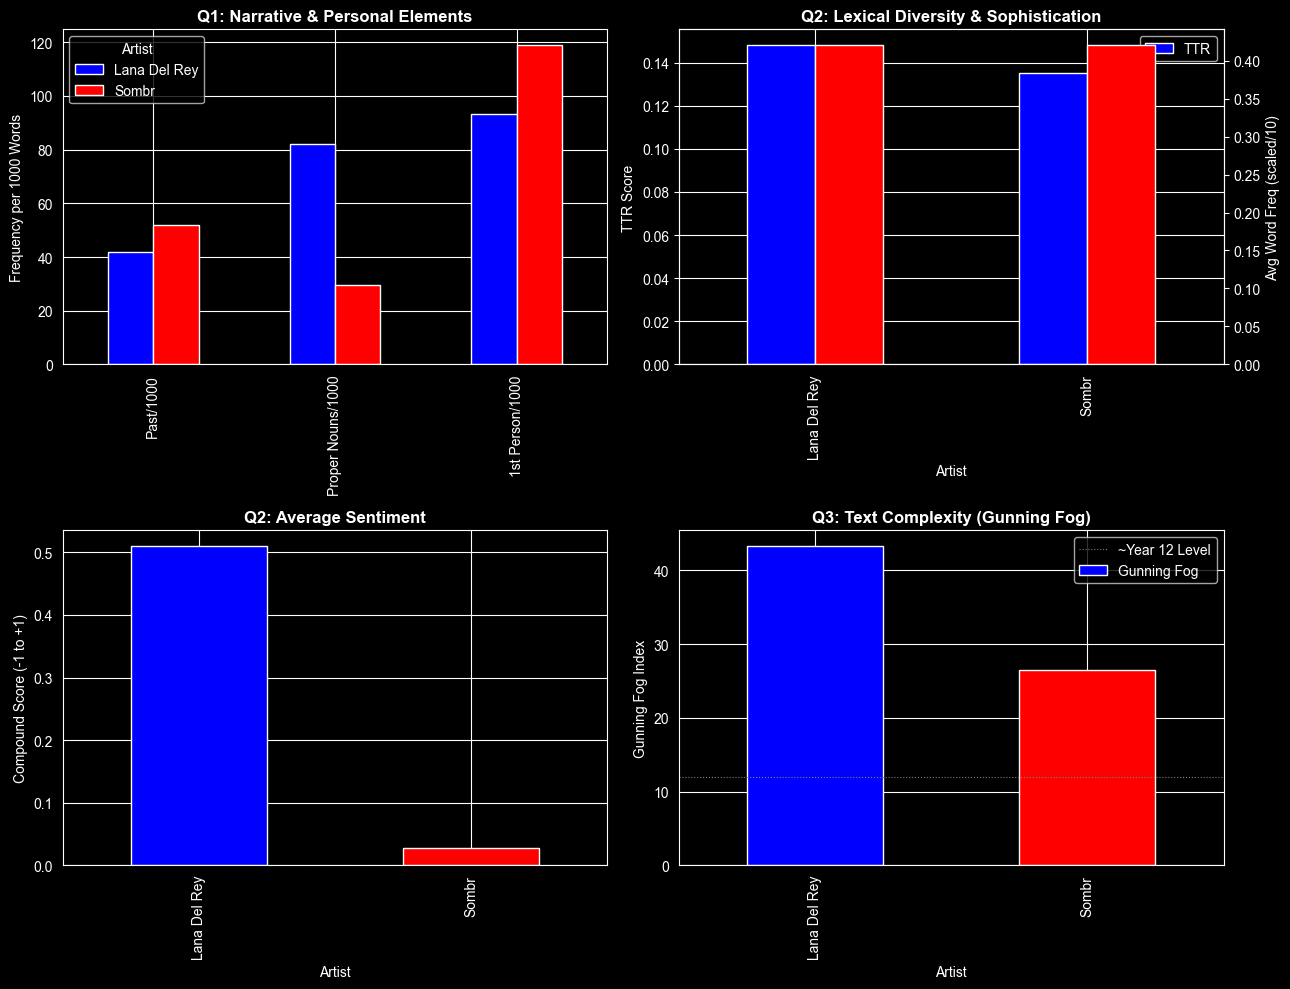

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Plot 1: Narrative Elements
metrics = ['Past/1000', 'Proper Nouns/1000', '1st Person/1000']
df.set_index('Artist')[metrics].T.plot(kind='bar', ax=axes[0,0], color=['blue', 'red'])
axes[0,0].set_title('Q1: Narrative & Personal Elements', fontweight='bold')
axes[0,0].set_ylabel('Frequency per 1000 Words')

# Plot 2: Lexical Metrics
df_lex = df.set_index('Artist')[['TTR', 'Avg Word Freq']].copy()
df_lex['Avg Word Freq'] = df_lex['Avg Word Freq'] / 10  # Scale for visualisation
df_lex.plot(kind='bar', ax=axes[0,1], color=['blue', 'red'], secondary_y='Avg Word Freq', mark_right=False)
axes[0,1].set_title('Q2: Lexical Diversity & Sophistication', fontweight='bold')
axes[0,1].set_ylabel('TTR Score')
axes[0,1].right_ax.set_ylabel('Avg Word Freq (scaled/10)')
axes[0,1].legend(['TTR', 'Avg Word Freq (scaled)'])

# Plot 3: Sentiment
df.set_index('Artist')['Avg Sentiment'].plot(kind='bar', ax=axes[1,0], color=['blue', 'red'])
axes[1,0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1,0].set_title('Q2: Average Sentiment', fontweight='bold')
axes[1,0].set_ylabel('Compound Score (-1 to +1)')

# Plot 4: Readability
df.set_index('Artist')['Gunning Fog'].plot(kind='bar', ax=axes[1,1], color=['blue', 'red'])
axes[1,1].axhline(y=12, color='grey', linestyle=':', linewidth=0.8, label='~Year 12 Level')
axes[1,1].set_title('Q3: Text Complexity (Gunning Fog)', fontweight='bold')
axes[1,1].set_ylabel('Gunning Fog Index')
axes[1,1].legend()

plt.tight_layout()
plt.show()

"A fog index of 12 requires the reading level of a United States high school senior (around 18 years old)", Gunning fog index Wikipedia: https://en.wikipedia.org/wiki/Gunning_fog_index

So, a fog index of 12 aligns with NZs Year 12/13 students (high school seniors).

## 5. Critical Reflection

This project aimed to determine whether the subjectively perceived stylistic differences between Lana Del Rey’s cinematic storytelling and Sombr’s raw introspection could be objectified through computational linguistics. The results provide a mixed and nuanced picture, offering strong quantitative support for some hypotheses while revealing unexpected patterns in other areas. The analysis partially supports the initial assumptions regarding narrative elements, but not in the straightforward manner anticipated. Contrary to expectations, Sombr’s lyrics demonstrated a higher frequency of past-tense verbs (51.75 per 1000 words) compared to Lana Del Rey’s (41.88 per 1000 words). This finding suggests that Sombr’s personal narratives may heavily involve reflection on prior events or states of self. However, the hypothesis regarding proper nouns was strongly validated, with Lana Del Rey using them at nearly triple the rate of Sombr (82.21 vs. 29.75 per 1000 words). This stark difference quantitatively captures her signature technique of anchoring songs in specific cultural and geographic references, helping to build her distinct mythos. As predicted, Sombr’s lyrics employed first-person pronouns more frequently (118.79 vs. 93.10 per 1000 words), solidifying the quantifiable distinction of their confessional style.

The investigation into lexical and emotional profiles provided complex and sometimes counterintuitive results. Linguistically, the metrics showed great similarity in core sophistication. Both artists possessed an identical average word frequency (4.2) and very similar dictionary coverage (0.867 vs. 0.855), indicating a comparable baseline use of common vocabulary. Lana Del Rey’s slightly higher Type-Token Ratio (0.148 vs. 0.135) points to marginally greater lexical diversity within the sampled songs. This similarity in lexical profile makes sense, as both artists work within the conventions of contemporary alternative music, where they will employ a largely shared and accessible vocabulary to connect with their audience.

The most significant difference emerged in sentiment analysis. To quantify emotional tone, the analysis used VADER's compound score, a normalised metric that aggregates individual word sentiments to produce a single value ranging from -1 (extremely negative) to +1 (extremely positive). Lana Del Rey's lyrics returned a strongly positive average compound score (0.510), whereas Sombr's neared neutral (0.027). This difference can be explained by the distinct lexical strategies each artist uses to convey melancholic themes. Lana Del Rey often employs positively valenced (hedonic tone), ornate vocabulary (e.g., "paradise," "dynamite," "blue velvet") to depict tragic or romantic scenarios, which VADER registers as positive. Conversely, Sombr articulates feelings of sadness and longing through plain, emotionally neutral words. For example, *"I don’t wanna get undressed for a new person"*, resulting in a near-neutral aggregate score. In both cases, the word-level sentiment analysis fails to capture the nuanced, context-dependent emotional narrative, highlighting a key limitation of automated tools for lyrical analysis. This difference makes sense given their core styles: Lana Del Rey's cinematic storytelling often aestheticises emotion within a grand, poetic framework, while Sombr's confessional approach presents a more direct and emotionally complex realism.

The most unequivocal finding concerns textual complexity where the Gunning Fog Index scores present a considerable contrast. Lana Del Rey’s lyrics (43.3) are vastly more syntactically complex than Sombr’s (26.5). This indicates that her work features longer sentences and a higher density of complex words, creating a dense, almost novelistic textual structure. Sombr’s lower score aligns with a more direct, conversational, and immediately accessible syntactic style. This finding supports the hypothesis that their narrative approaches manifest in fundamental structural differences, with Lana Del Rey embracing formal complexity and Sombr prioritising structural clarity.

These findings must be contextualised by the inherent limitations of applying computational methods to artistic texts. A primary constraint is the use of tools like VADER, which is designed for standard prose and operates on word-level sentiment. As demonstrated in the results, this leads to a fundamental disconnect, where it can score a heartbreaking narrative as "positive" if it uses lush descriptors, and a plainly stated emotional void as "neutral." This presents a challenge in digital humanities, measuring meaning versus lexical valence. Secondly, analysing lyrics as standalone text removes the essential musical context of melody and delivery, which greatly shapes emotional perception. Finally, while metrics like Gunning Fog measure syntactic complexity, they cannot assess poetic or rhythmic sophistication, a key aspect of lyrical craft.

In conclusion, this project successfully objectifies key aspects of the artists' contrasting styles. It confirms Lana Del Rey’s use of specific, name-dropping imagery and her exceptional syntactic complexity, while validating Sombr’s more personal, pronoun-driven focus. The analysis also complicates initial assumptions, revealing Sombr’s deep engagement with the past tense and demonstrating that core lexical sophistication is not a primary differentiator. Crucially, the unexpected sentiment results present a significant methodological insight, where computational analysis is powerful for identifying stylistic mechanisms (like diction and syntax) but remains limited in interpreting emotional effect without human contextual understanding. Future research could build on this by analysing full discographies or developing genre-specific sentiment lexicons. Ultimately, this analysis does not reduce art to data but uses quantitative evidence to deepen, challenge, and substantiate our understanding of lyrical craft.

This work is publicly accessible via GitHub: https://github.com/jescsk/LSCI220/tree/main/A3